In [2]:
import numpy as np
import pandas as pd

#import seaborn as sns
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix

plt.style.use('classic')

In [3]:
df=pd.read_csv('.././housing.csv',sep=',')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


# **Sumarização estatística: medidas de localização e dispersão**

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**Adicionando medidas de dispersão:**
1.   Intervalo ou range.
2.   Coeficiente de variação.
3.   Kurtosis ou Coeficiente de Assimetria.
4.   Skewness ou Coeficiente de assimetria.





In [6]:
# obtendo a lista de nomes das features do dataset:
cols=df.columns.to_list()
cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [7]:
dt=df.describe()
dt.loc['cv']=dt.loc['std'].values/dt.loc['mean'].values # adição do coeficiente de variação (cv)
dt.loc['range']=(df[cols[:-1]].max()-df[cols[:-1]].min()).values # adição do intervalo (range)
dt.loc['skewness']=df[cols[:-1]].skew(axis=0).values # adição do coeficiente de assimetria (medida de forma)
dt.loc['kurtosis']=df[cols[:-1]].kurt(axis=0).values # adição do coeficiente de curtose (medida de forma)
dt.round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00
cv,-0.02,0.06,0.44,0.83,0.78,0.79,0.77,0.49,0.56
range,10.04,9.41,51.00,39318.00,6444.00,35679.00,6081.00,14.50,485002.00


**Rotacionando a Tabela de Sumarização**

In [8]:
dt.T.round(2)

,count,mean,std,min,25%,50%,75%,max,cv,range,skewness,kurtosis
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31,-0.02,10.04,-0.30,-1.33
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95,0.06,9.41,0.47,-1.12
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00,0.44,51.00,0.06,-0.80
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00,0.83,39318.00,4.15,32.63
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00,0.78,6444.00,3.46,21.99
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00,0.79,35679.00,4.94,73.55
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00,0.77,6081.00,3.41,22.06
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00,0.49,14.50,1.65,4.95
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00,0.56,485002.00,0.98,0.33


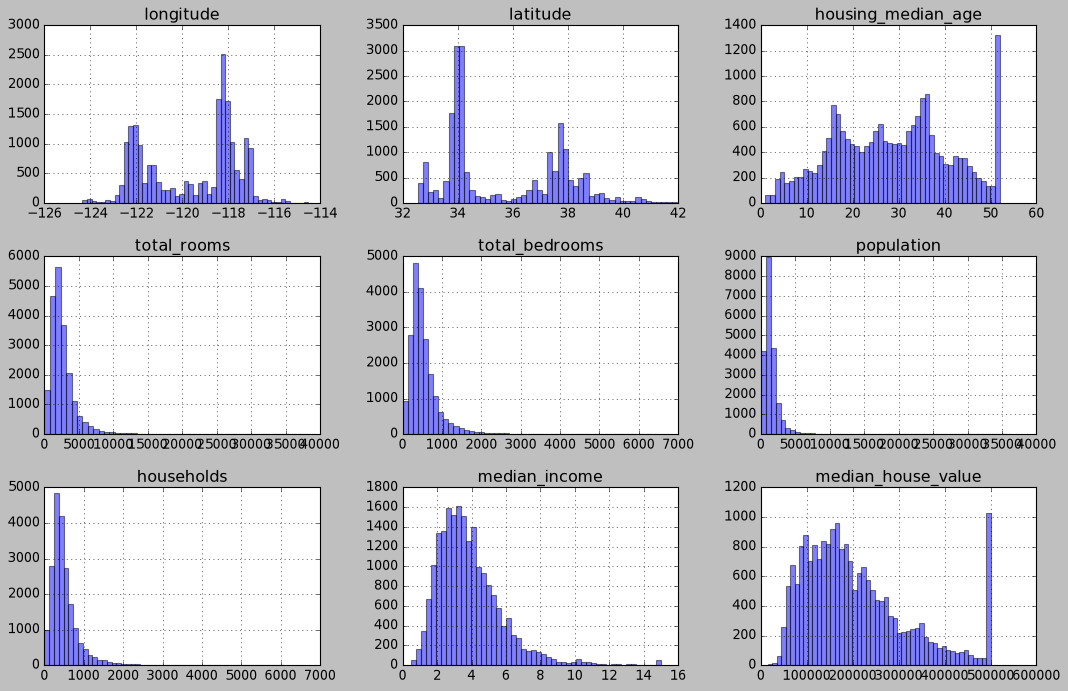

In [9]:
df.hist(bins=50,figsize=(16,10), alpha=0.5)
plt.show()

# **Análise de correlação: medidas de associação**

In [10]:
df[cols[:-1]].corr("pearson").round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.00,-0.92,-0.11,0.04,0.07,0.10,0.06,-0.02,-0.05
latitude,-0.92,1.00,0.01,-0.04,-0.07,-0.11,-0.07,-0.08,-0.14
housing_median_age,-0.11,0.01,1.00,-0.36,-0.32,-0.30,-0.30,-0.12,0.11
total_rooms,0.04,-0.04,-0.36,1.00,0.93,0.86,0.92,0.20,0.13
total_bedrooms,0.07,-0.07,-0.32,0.93,1.00,0.88,0.98,-0.01,0.05
population,0.10,-0.11,-0.30,0.86,0.88,1.00,0.91,0.00,-0.02
households,0.06,-0.07,-0.30,0.92,0.98,0.91,1.00,0.01,0.07
median_income,-0.02,-0.08,-0.12,0.20,-0.01,0.00,0.01,1.00,0.69
median_house_value,-0.05,-0.14,0.11,0.13,0.05,-0.02,0.07,0.69,1.00


In [11]:
df[cols[:-1]].corr("spearman").round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.00,-0.88,-0.15,0.04,0.06,0.12,0.06,-0.01,-0.07
latitude,-0.88,1.00,0.03,-0.02,-0.06,-0.12,-0.07,-0.09,-0.17
housing_median_age,-0.15,0.03,1.00,-0.36,-0.31,-0.28,-0.28,-0.15,0.07
total_rooms,0.04,-0.02,-0.36,1.00,0.92,0.82,0.91,0.27,0.21
total_bedrooms,0.06,-0.06,-0.31,0.92,1.00,0.87,0.98,-0.01,0.09
population,0.12,-0.12,-0.28,0.82,0.87,1.00,0.90,0.01,0.00
households,0.06,-0.07,-0.28,0.91,0.98,0.90,1.00,0.03,0.11
median_income,-0.01,-0.09,-0.15,0.27,-0.01,0.01,0.03,1.00,0.68
median_house_value,-0.07,-0.17,0.07,0.21,0.09,0.00,0.11,0.68,1.00


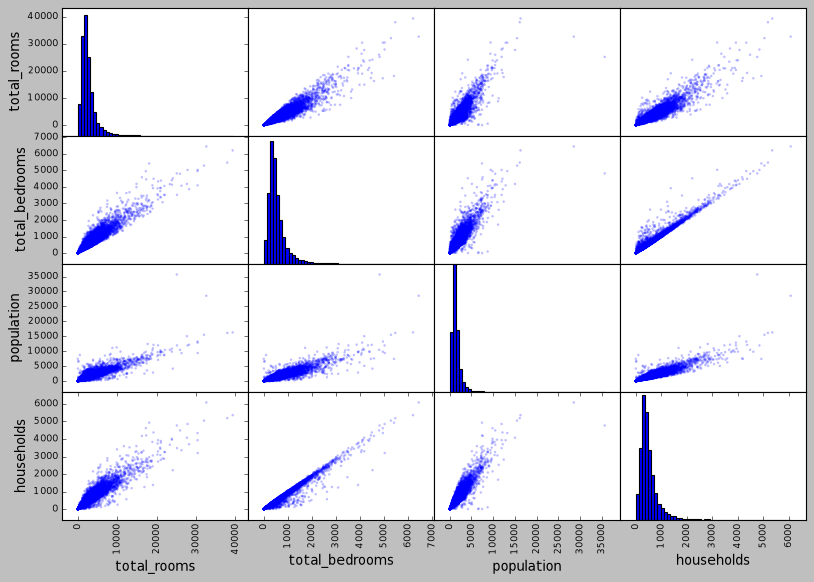

In [12]:
attributes=["total_rooms","total_bedrooms","population","households"]

scatter_matrix(df[attributes], figsize=(12, 8),range_padding=0.2,color='blue',
               hist_kwds={'bins':50,'color':'blue','alpha':1.0},alpha=0.25)
plt.show()

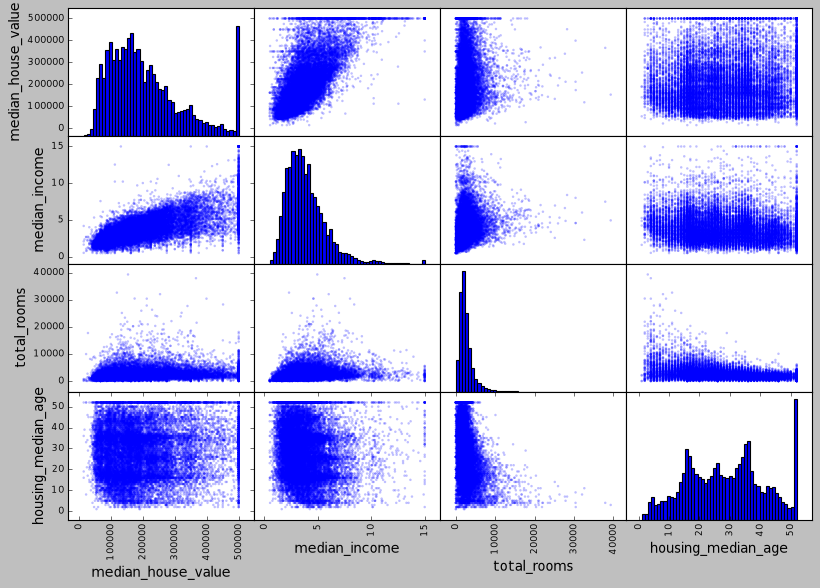

In [13]:
attributes=["median_house_value", "median_income", "total_rooms","housing_median_age"]

scatter_matrix(df[attributes], figsize=(12, 8),range_padding=0.2,color='blue',
               hist_kwds={'bins':50,'color':'blue','alpha':1.0},alpha=0.25)
plt.show()